#### gradient descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(f, grad_f, x0, eta, n_iters):
  x = np.array(x0, dtype=float)
  x_sq = [x.copy()]
  f_sq = [f(x)]
  for _ in range(n_iters):
    grad_x = grad_f(x)
    x = x - eta * grad_x
    x_sq.append(x.copy())
    f_sq.append(f(x))
  return np.array(x_sq), np.array(f_sq)

Test 1: $$f(x, y) = x^2 + y^2 + xy$$

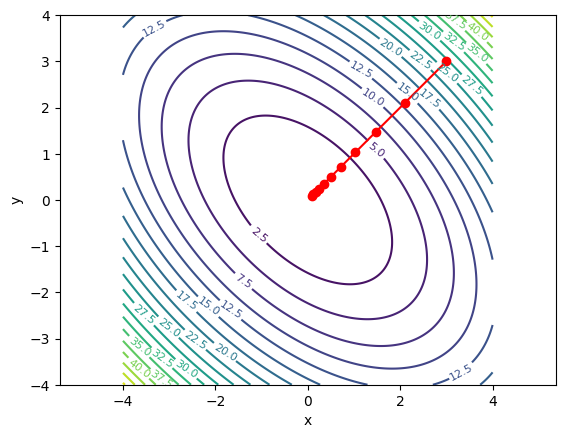

In [2]:
def func(x0):
  x, y = x0
  return x**2+y**2+x*y

def func_grad(x0):
  x, y = x0
  return np.array([2*x+y, x+2*y])

x_sq, f_sq = gradient_descent(func, func_grad, x0=[3, 3], eta=0.1, n_iters=10)

grid_x = np.linspace(-4, 4, 400)
grid_y = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(grid_x, grid_y)
Z = X**2+Y**2+X*Y

plt.figure()
CS = plt.contour(X, Y, Z, levels=20)
plt.clabel(CS, inline=True, fontsize=8)
plt.plot(x_sq[:,0], x_sq[:,1], marker='o', color='red')
plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
plt.show()

Test 2: $$f(x, y) = (1-x)^2 + 100(y-x^2)^2 $$

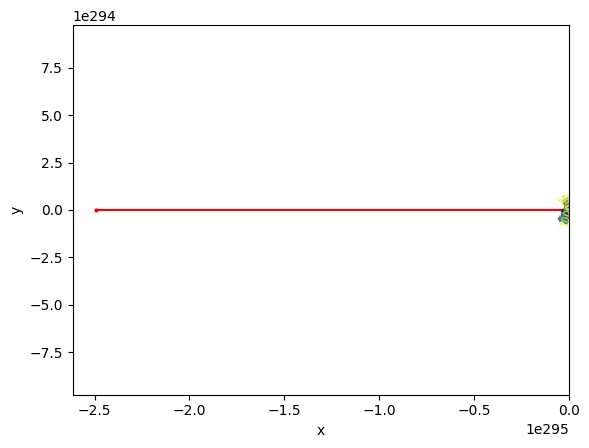

In [4]:
import numpy as np
np.seterr(all="ignore")   # warning

def func_r(x0):
  x, y = x0
  return (1-x)**2+100*(y-x**2)**2

def func_r_grad(x0):
  x, y = x0
  dx = -2*(1-x)-400*x*(y-x**2)
  dy = 200*(y-x**2)
  return np.array([dx, dy])

x_r_sq, f_r_sq = gradient_descent(func_r, func_r_grad, x0=[3, 3], eta=0.1, n_iters=100)

grid_x = np.linspace(-2, 4, 600)
grid_y = np.linspace(-2, 4, 600)
X, Y = np.meshgrid(grid_x, grid_y)
Z = (1-X)**2 + 100*(Y-X**2)**2

plt.figure()
CS = plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20))
plt.clabel(CS, inline=True, fontsize=7, fmt="%.1f")
plt.plot(x_r_sq[:,0], x_r_sq[:,1], marker='o', markersize=2, color='red')
plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
plt.show()